# Smart Habit & Productivity Analyzer
This project analyzes daily habits and predicts productivity using Machine Learning

### 1. Introduction
### 2. Dataset Overview
### 3. Exploratory Data Analysis
### 4. Data Preprocessing
### 5. Regression Model
### 6. Classification Models
### 7. Clustering Analysis
### 8. Recommendation System
### 9. Conclusion

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
data= {
    'study_hours': [2, 4, 6, 8, 3, 5, 7, 1, 9, 4],
    'sleep_hours': [5, 6, 7, 8, 5, 6, 7, 4, 8, 6],
    'screen_time': [5, 4, 3, 2, 6, 4, 3, 7, 2, 5],
    'exercise': ['no','yes','yes','yes','no','yes','yes','no','yes','no'],
    'productivity_score': [40, 55, 70, 85, 45, 60, 75, 30, 90, 50]
}

df=pd.DataFrame(data)
df

,study_hours,sleep_hours,screen_time,exercise,productivity_score
0,2,5,5,no,40
1,4,6,4,yes,55
2,6,7,3,yes,70
3,8,8,2,yes,85
4,3,5,6,no,45
5,5,6,4,yes,60
6,7,7,3,yes,75
7,1,4,7,no,30
8,9,8,2,yes,90
9,4,6,5,no,50


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   study_hours         10 non-null     int64
 1   sleep_hours         10 non-null     int64
 2   screen_time         10 non-null     int64
 3   exercise            10 non-null     str  
 4   productivity_score  10 non-null     int64
dtypes: int64(4), str(1)
memory usage: 532.0 bytes


In [6]:
df.describe()

,study_hours,sleep_hours,screen_time,productivity_score
count,10.000000,10.000000,10.00000,10.000000
mean,4.900000,6.200000,4.10000,60.000000
std,2.601282,1.316561,1.66333,19.720266
min,1.000000,4.000000,2.00000,30.000000
25%,3.250000,5.250000,3.00000,46.250000
50%,4.500000,6.000000,4.00000,57.500000
75%,6.750000,7.000000,5.00000,73.750000
max,9.000000,8.000000,7.00000,90.000000


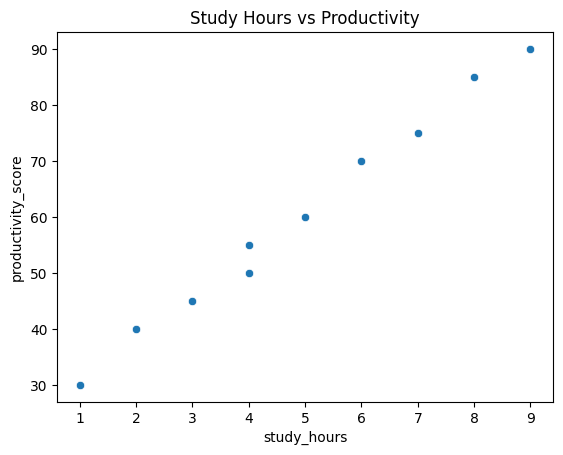

In [8]:
sns.scatterplot(x='study_hours', y='productivity_score', data=df)
plt.title("Study Hours vs Productivity")
plt.show()

### Observations:
- As study hours increases, productivity increases.

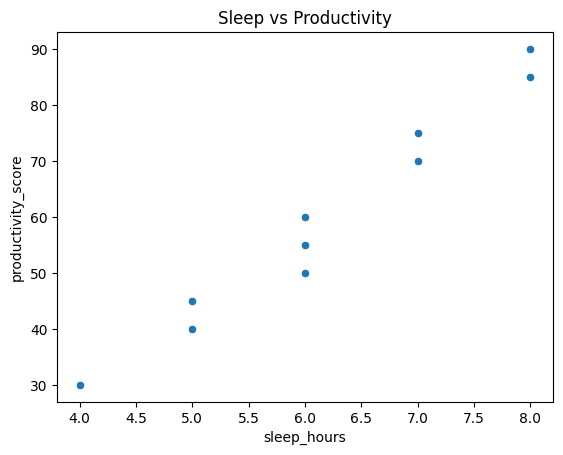

In [9]:
sns.scatterplot(x='sleep_hours', y='productivity_score', data=df)
plt.title("Sleep vs Productivity")
plt.show()

### Observations:
- More sleep leads to better productivity.

In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['exercise'] = le.fit_transform(df['exercise'])

df

,study_hours,sleep_hours,screen_time,exercise,productivity_score
0,2,5,5,0,40
1,4,6,4,1,55
2,6,7,3,1,70
3,8,8,2,1,85
4,3,5,6,0,45
5,5,6,4,1,60
6,7,7,3,1,75
7,1,4,7,0,30
8,9,8,2,1,90
9,4,6,5,0,50


In [11]:
X = df.drop('productivity_score', axis=1)
y = df['productivity_score']

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

In [13]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [14]:
y_pred = model.predict(X_test)
y_pred

array([90., 55.])

In [15]:
from sklearn.metrics import mean_absolute_error

print("MAE:", mean_absolute_error(y_test, y_pred))

MAE: 1.4210854715202004e-14


### Observation:
- The model achieved very low error because the dataset is small and follows a simple linear pattern.
- In real-world scenarios, error would be higher due to complex relationships.

In [16]:
df['productivity_level'] = pd.cut(
    df['productivity_score'],
    bins=3,
    labels=[0, 1, 2]
)

df

,study_hours,sleep_hours,screen_time,exercise,productivity_score,productivity_level
0,2,5,5,0,40,0
1,4,6,4,1,55,1
2,6,7,3,1,70,1
3,8,8,2,1,85,2
4,3,5,6,0,45,0
5,5,6,4,1,60,1
6,7,7,3,1,75,2
7,1,4,7,0,30,0
8,9,8,2,1,90,2
9,4,6,5,0,50,0


In [17]:
X_cls = df.drop(['productivity_score', 'productivity_level'], axis=1)
y_cls = df['productivity_level']

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42
)

In [21]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression()
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

In [22]:
from sklearn.metrics import accuracy_score

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))

Logistic Regression Accuracy: 1.0


In [23]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.5


In [24]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred_dt))

[[0 0 0]
 [1 0 0]
 [0 0 1]]


### Observation:
- Logistic Regression achieved perfect accuracy due to the simplicity and small size of the dataset.
- Decision Tree performed worse, likely due to overfitting and limited data.
- Results may not generalize well because of the small dataset.

In [25]:
X_cluster = df[['study_hours', 'sleep_hours', 'screen_time']]

In [26]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_cluster)

df['cluster'] = kmeans.labels_

df

,study_hours,sleep_hours,screen_time,exercise,productivity_score,productivity_level,cluster
0,2,5,5,0,40,0,2
1,4,6,4,1,55,1,1
2,6,7,3,1,70,1,0
3,8,8,2,1,85,2,0
4,3,5,6,0,45,0,2
5,5,6,4,1,60,1,1
6,7,7,3,1,75,2,0
7,1,4,7,0,30,0,2
8,9,8,2,1,90,2,0
9,4,6,5,0,50,0,1


In [27]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_cluster)

df['cluster'] = kmeans.labels_

df

,study_hours,sleep_hours,screen_time,exercise,productivity_score,productivity_level,cluster
0,2,5,5,0,40,0,2
1,4,6,4,1,55,1,1
2,6,7,3,1,70,1,0
3,8,8,2,1,85,2,0
4,3,5,6,0,45,0,2
5,5,6,4,1,60,1,1
6,7,7,3,1,75,2,0
7,1,4,7,0,30,0,2
8,9,8,2,1,90,2,0
9,4,6,5,0,50,0,1


In [30]:
df.groupby('cluster').mean(numeric_only=True)

,study_hours,sleep_hours,screen_time,exercise,productivity_score
cluster,,,,,
0,7.500000,7.500000,2.500000,1.000000,80.000000
1,4.333333,6.000000,4.333333,0.666667,55.000000
2,2.000000,4.666667,6.000000,0.000000,38.333333


### Clustering Insight:

- Cluster 0 represents highly productive individuals with good habits.
- Cluster 1 represents moderately productive individuals with average habits.
- Cluster 2 represents low productivity individuals with poor habits.

Key findings:
- Higher study and sleep hours improve productivity.
- Increased screen time negatively impacts productivity.
- Exercise is associated with better performance.

In [32]:
def recommend(study, sleep, screen):
    if study < 3:
        print("Increase study hours")
    if sleep < 6:
        print("Get more sleep")
    if screen > 5:
        print("Reduce screen time")
    if study >= 6 and sleep >= 7:
        print("You are on the right track!")

In [33]:
recommend(2, 5, 6)

Increase study hours
Get more sleep
Reduce screen time


## Conclusion

- Study hours and sleep have a strong positive impact on productivity.
- Screen time negatively affects productivity.
- Logistic Regression performed well due to simple data patterns.
- Clustering revealed three types of users: high, medium, and low productivity groups.
- A simple recommendation system was built to guide users toward better habits.

This project demonstrates the use of regression, classification, and clustering techniques in a real-world scenario.